In [ ]:
# import classy module
import classy
print (classy.__version__)

In [1]:
# import classy module
from classy import Class
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# create instance of the class "Class"
LambdaCDM = Class()
# pass input parameters
LambdaCDM.set({'output':'mPk','P_k_max_1/Mpc':200,'z_max_pk':3.5})
LambdaCDM.set({'non_linear':'oneloopPT'})
LambdaCDM.set({'has_rsd':'yes'})
LambdaCDM.set({'eft_compute_loop_matrices':'yes'})
LambdaCDM.set({'eft_enable_mu_approximation':'yes'})
LambdaCDM.set({'eft_write_loop_matrices':'no'})
LambdaCDM.set({'eft_direct_integration':'no'})
# run class
LambdaCDM.compute()

In [3]:
# Choose parameters relevant for P_oneloop
#
# vector of z values
z = np.array([0.,1.],'float64')
# number of mu values from 0 to 1
mu_size = 3
# number of k values, k_min and k_max in 1/Mpc
k_size = 100
kmin=0.001071519
kmax=0.9332543
# parameters of oneloop model
biases = np.array([1,-0.5,0.3,0.8])
counterterms = np.array([-10,20,20,20,0,0,0])
R2=5.
cs2=0.
has_rsd = True

In [4]:
# Put the input in the right format and call eft_job_powerspectrum_wedges_grid()
#
# array z[index_z]
z_size = len(z)
#
# create array mu[index_z + z_size*index_mu]
muvec = np.zeros(mu_size,'float64')
for index_mu in range(mu_size):
    muvec[index_mu]= index_mu/(mu_size-1.)
mu = np.zeros(z_size*mu_size,'float64')    
for index_z in range(z_size):
    for index_mu in range(mu_size):
        mu[index_z + z_size*index_mu] = muvec[index_mu]
#
# create array k[index_z + z_size*(index_mu + mu_size*index_k)]
kvec = np.zeros(k_size,'float64')
for index_k in range(k_size):
    kvec[index_k]=kmin*np.exp(index_k/(k_size-1.)*np.log(kmax/kmin))
k = np.zeros(z_size*mu_size*k_size,'float64')        
for index_k in range(k_size):
    for index_z in range(z_size):
        for index_mu in range(mu_size):
            k[index_z + z_size*(index_mu + mu_size*index_k)] = kvec[index_k]
#    
pkmuz = LambdaCDM.eft_job_powerspectrum_wedges_grid(mu,
                                                    k,
                                                    z,
                                                    mu_size,
                                                    k_size,
                                                    z_size,
                                                    'Pdd_hh_rsd',
                                                    biases,
                                                    counterterms,
                                                    R2,
                                                    cs2,
                                                    has_rsd)

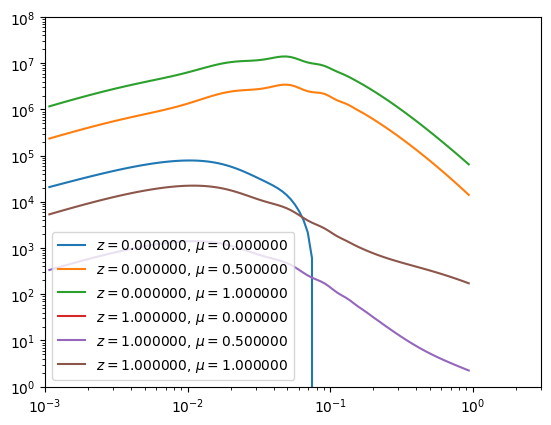

In [5]:
# plot the result
kk = np.zeros(k_size,'float64')
pk = np.zeros(k_size,'float64')
#for index_z in range(1):
for index_z in range(z_size):
    for index_mu in range(mu_size):
        for index_k in range(k_size):
            kk[index_k] = k[index_z + z_size*(index_mu + mu_size*index_k)]
            pk[index_k] = pkmuz[index_z + z_size*(index_mu + mu_size*index_k)]
        plt.loglog(kk,pk,label=r"$z=%f$, $\mu=%f$"%(z[index_z],mu[index_z+z_size*index_mu]))
plt.xlim([1.e-3,3.]) 
plt.ylim([1.e0,1e8]) 
plt.legend()